<a href="https://colab.research.google.com/github/nomanabdullah04/DeepLearning/blob/main/Exploding_Gradient_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 43. The Exploding Gradient Problem: Theory, Chain Rule & Mathematical Intuition

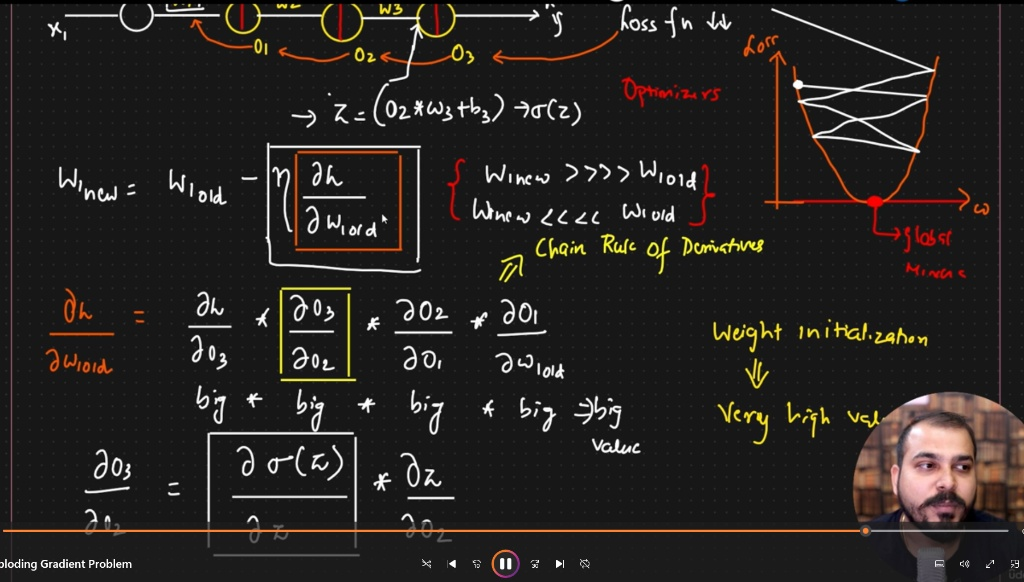

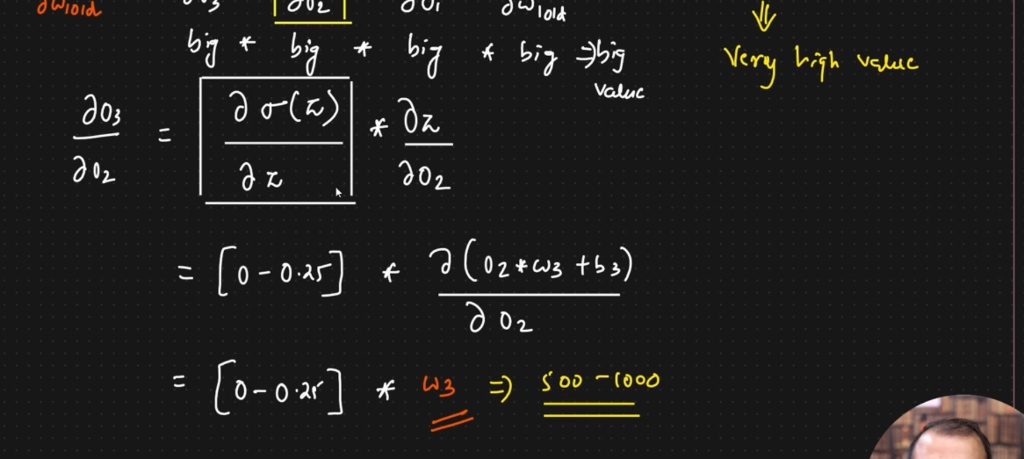

### **1. What is the Exploding Gradient Problem?**
While the vanishing gradient problem causes early layers to stop learning because gradients shrink to zero, the **Exploding Gradient Problem** happens when the gradients grow exponentially large during backpropagation.

As shown in the lecture graph, instead of smoothly converging, extreme gradients cause weight updates to bounce violently and overshoot the minimum entirely, destabilizing the model.

### **2. Chain Rule Derivation and Why It Happens**
During backpropagation through a deep neural network, the chain rule multiplies derivatives across multiple layers:

$$\frac{\partial L}{\partial W_{1_{old}}} = \frac{\partial L}{\partial O_3} * \frac{\partial O_3}{\partial O_2} * \frac{\partial O_2}{\partial O_1} * \frac{\partial O_1}{\partial W_{1_{old}}}$$

* **Improper Weight Initialization:** If weights (e.g., $W_3$) are initialized with very high values (e.g., $500$ to $1000$), the partial derivative terms evaluate to large numbers ("big * big * big * big $\Rightarrow$ very big value").
* **Expanding Chain Product:**
  $$\frac{\partial O_3}{\partial O_2} = \frac{\partial \sigma(z)}{\partial z} * \frac{\partial z}{\partial O_2}$$
  $$\frac{\partial O_3}{\partial O_2} = [0 \text{ to } 0.25] * \frac{\partial (O_2 \times W_3 + b_3)}{\partial O_2} = [0 \text{ to } 0.25] * W_3$$
  If $W_3$ is extremely large, this product scales up aggressively.

### **3. Consequences on Weight Updation**
Using the gradient descent update rule:
$$W_{new} = W_{old} - \eta \left( \frac{\partial L}{\partial W_{old}} \right)$$

* Because the gradient term is massively inflated, $W_{new} \ggg W_{old}$ (or $W_{new} \lll W_{old}$).
* This causes numerical overflow (resulting in `NaN` values) and ruins model training.

### **4. How to Prevent Exploding Gradients?**
1. **Gradient Clipping:** Capping the gradient values so they cannot exceed a specific threshold during backpropagation.
2. **Proper Weight Initialization:** Using techniques like **Xavier / Glorot** or **He Initialization** instead of random high values.
3. **Using ReLU Activation:** Helps avoid compounding saturation issues found in sigmoid/tanh.
4. **Batch Normalization:** Normalizes layer inputs to keep values stable.